# Automated Cell Segmentation with Cellpose

## Introduction

Welcome to the 5<sup>th</sup> notebook in the Bioimage analysis in Python course! This notebook focuses on automated cell segmentation using Cellpose, a state-of-the-art deep learning tool that has revolutionized cell segmentation across diverse imaging conditions.

## Why Cell Segmentation Matters

Cell segmentation is the foundation of quantitative microscopy analysis:
- **Individual cell analysis**: Measure properties of single cells rather than population averages
- **Spatial relationships**: Understand cell-cell interactions and tissue organization
- **Dynamic processes**: Track cells over time to study division, migration, death
- **Drug screening**: Quantify cellular responses to treatments at single-cell resolution
- **Disease diagnosis**: Automated analysis for pathology and clinical applications

## The Segmentation Challenge

Traditional segmentation methods struggle with:
- **Diverse cell types**: Different morphologies require different approaches
- **Imaging conditions**: Varying contrast, resolution, and staining protocols
- **Crowded fields**: Overlapping or touching cells
- **Artifacts**: Uneven illumination, debris, imaging noise

## Cellpose: A Game-Changer

### What Makes Cellpose Special
- **Generalist model**: Works across cell types without retraining
- **Flow-based approach**: Predicts gradient flows to find cell boundaries
- **Size-agnostic**: Automatically adapts to different cell sizes
- **Robust performance**: Handles challenging imaging conditions
- **Easy to use**: Minimal parameter tuning required

### Key Concepts
- **Flow fields**: Gradients that point toward cell centers
- **Heat maps**: Probability maps indicating cell regions
- **Size rescaling**: Automatic adaptation to cell diameter
- **GPU acceleration**: Fast processing for large datasets

## Learning Objectives

By completing this notebook, you will:

1. **Install and configure** Cellpose for GPU-accelerated segmentation
2. **Load and examine** multidimensional fluorescence microscopy data
3. **Apply** Cellpose segmentation with optimal parameters
4. **Understand** the impact of preprocessing on segmentation quality
5. **Implement** traditional preprocessing techniques (background subtraction, CLAHE, filtering)
6. **Visualize** segmentation results effectively
7. **Export** segmented data for downstream analysis

## Course Workflow

This notebook demonstrates a complete segmentation pipeline:

1. **Environment Setup**: Install Cellpose and configure dependencies
2. **Data Loading**: Import and examine fluorescence microscopy data
3. **Direct Segmentation**: Apply Cellpose with default settings
4. **Results Visualization**: Display segmentation masks and quality assessment
5. **Preprocessing Pipeline**: Implement traditional image enhancement
6. **Comparative Analysis**: Evaluate preprocessing impact on segmentation
7. **Data Export**: Save results for further analysis

## Traditional vs. Modern Approaches

### Traditional Image Processing
- Background subtraction (rolling ball)
- Contrast enhancement (CLAHE)
- Noise reduction (Gaussian filtering)
- Thresholding and watershed

### Modern Deep Learning
- End-to-end neural networks
- Learned feature representations
- Robust to imaging variations
- Minimal manual parameter tuning

### Best Practice: Hybrid Approach
This notebook demonstrates how combining traditional preprocessing with modern ML often yields optimal results.

## Expected Outcomes

After completing this notebook, you will have:
- Practical experience with state-of-the-art cell segmentation
- Understanding of when and how to preprocess images
- Skills to optimize segmentation for your specific data
- Knowledge to integrate segmentation into larger analysis pipelines

**Let's dive into the world of automated cell segmentation!**


## Setup

First, we will connect to the correct runtime environment. Since we we are going to use deep learning, we would really benefit from having a GPU. Therefore, we will connect to a GPU runtime environment.

Select a Python with GPU runtime

- Click on Connect > Change the runtime

![Change runtime](https://drive.google.com/uc?export=view&id=1Rgloj9hRS-FZD9dQFN2IZXwSWs_rd8Rs)

- Select Runtime Python and with a GPU

![Select GPU runtime](https://drive.google.com/uc?export=view&id=13fBkTvz3gmtySh9QQWBDNT_msqD0xOiX)

Next, we install the necessary libraries.

In [1]:
!which python

try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

print(f"Running on colab {IN_COLAB}")

/cygdrive/c/Users/u0094799/.conda/envs/biomage-training-colab/python
Running on colab False


In [ ]:
!pip install bioio==3.0.0 bioio-czi==2.4.0 bioio-ome-tiff==1.4.0
!pip install cellpose

### Download the image dataset
We will work with a demo microscopy dataset in which HeLa cells have been stained using DAPI, and tubulin and mitochondria antibodies. Hereto, we will download the image dataset into our Google Drive.

In [2]:
import gdown

# a file
url = "https://drive.google.com/uc?id=1tR0yOZ7vOwMz43RacDNw77oGi50pbBrd"
if IN_COLAB :
    image_path = "/content/hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568_40x.czi"
    gdown.download(url, image_path)

## Loading image data

We will work with the same image as in notebooks 2 and 3. We load the image in, select the DAPI (nuclei) and tubulin (cytoplasm) channels, and convert them to a numpy array.

In [3]:
from bioio import BioImage
import numpy as np

if IN_COLAB :
    image_path = "/content/hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568_40x.czi"
else:
    image_path = "../data/hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568_40x.czi"


# Get a BioImage object
img = BioImage(image_path)  # selects the first scene found

print("img shape: {}".format(img.shape))
print("Dimension order: {}".format(img.dims.order))

image_scale = [img.physical_pixel_sizes.Z, img.physical_pixel_sizes.Y, img.physical_pixel_sizes.X]
print("Dimension order: {}".format(image_scale))

color_map = 'cyan'

nuclei_cell_image = img.get_image_data("CZYX", T=0)[[1, 2], :, :, :].squeeze()
print(nuclei_cell_image.shape)

img shape: (1, 3, 14, 512, 512)
Dimension order: TCZYX
Dimension order: [1.0, 0.4151329104819196, 0.4151329104819196]
(2, 14, 512, 512)


### Maximum intensity projection
Now, create a macimum intensity projection of the image along the Z axis. Call it `nuclei_cell_image_MIP`.


In [4]:
# Exercise cell: Obtain a maximum intensity projection of the image along the Z axis
nuclei_cell_image_MIP = np.max(nuclei_cell_image, axis=1)
print(nuclei_cell_image_MIP.shape)

(2, 512, 512)


### Cell Segmentation using Cellpose

Now it is time to create a Cellpose model, load in the pretrained weights, and run it to segment the cells in our maximum intensity projection.



In [44]:
from cellpose import models

# Initialize model with GPU support based on argument
cyto_model = models.CellposeModel(gpu=True)

# Define the parameters
diameter = 60 # in pixels, set to 0 to let the model estimate the diameter
channel_axis = 0 # first axis is the channel axis
do_3D = False # enable 3D processing
cellprob_threshold = 0.0 # all pixels with value above threshold kept for masks, decrease to find more and larger masks. Defaults to 0.0.
flow_threshold = 0.4 #if do_3D and flow3D_smooth>0, smooth flows with gaussian filter of this stddev. Defaults to 0.

# Run segmentation in 2D
cyto_labels, flows, styles = cyto_model.eval(
    nuclei_cell_image_MIP,
    diameter=diameter,
    channel_axis=channel_axis,
    do_3D=do_3D,
    cellprob_threshold=cellprob_threshold,
    flow_threshold=flow_threshold,
)

Resizing is depricated in v4.0.1+


Lets visualize the results.

You will see the predicted cell outlines, the corresponding cell masks, and the predicted flows. These flows were predicted by the model and were used to calculate the cell mask boundaries.

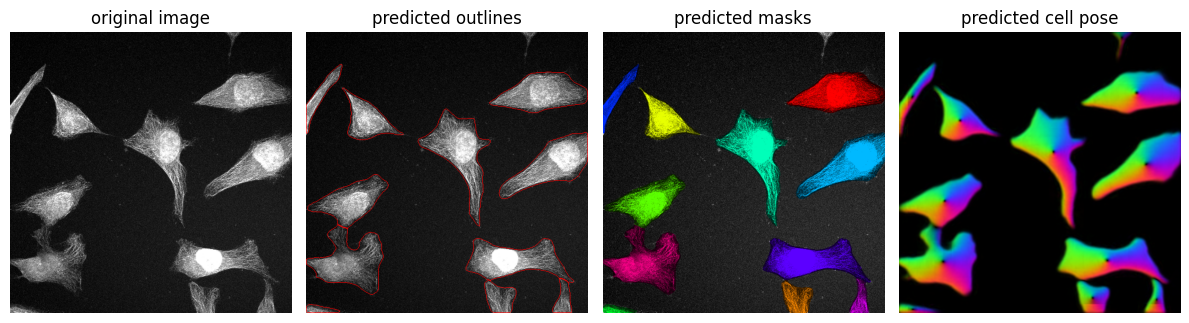

In [45]:


%matplotlib inline
import matplotlib.pyplot as plt
from cellpose import plot

channels = [0,1]
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, nuclei_cell_image_MIP.squeeze(), cyto_labels, flows[0], channels=channels)
plt.tight_layout()
plt.show()



## Store the segmentation masks

With `bioio`, we will now store the segmentation results.

In [46]:
import bioio_base as biob
from bioio_ome_tiff.writers import OmeTiffWriter
import os

if IN_COLAB :
    output_path="/content/cellpose_cell_masks.ome.tiff"
else:
    output_path="../data/cellpose_cell_masks.ome.tiff"

write_dim_order = "YX"  # required, the dimension order to write the data in
pixel_size = biob.types.PhysicalPixelSizes(img.physical_pixel_sizes.Z, img.physical_pixel_sizes.Y, img.physical_pixel_sizes.X)  # optional, Z, Y, X in microns

print(cyto_labels.shape)
OmeTiffWriter.save(
        cyto_labels,
        output_path,
        write_dim_order,
        physical_pixel_sizes=pixel_size,
    )



(512, 512)


# Exclude the cells touching the border

In [47]:
from skimage.segmentation import clear_border
from skimage.measure import label

cyto_labels = clear_border(cyto_labels)
cyto_labels = label(cyto_labels)


## Segment the nuclei using thte DAPI channel only

In [48]:
nuclei_image_MIP = nuclei_cell_image_MIP[1,:,:]
# Define the parameters
diameter = 60 # in pixels, set to 0 to let the model estimate the diameter
channel_axis = None # first axis is the channel axis
do_3D = False # enable 3D processing
cellprob_threshold = 0.0 # all pixels with value above threshold kept for masks, decrease to find more and larger masks. Defaults to 0.0.
flow_threshold = 0.4 #if do_3D and flow3D_smooth>0, smooth flows with gaussian filter of this stddev. Defaults to 0.

# Run segmentation in 2D
nuclei_labels, flows_nuclei, styles_nuclei = cyto_model.eval(
    nuclei_image_MIP.squeeze(),
    diameter=diameter,
    channel_axis=channel_axis ,
    do_3D=do_3D,
    cellprob_threshold=cellprob_threshold,
    flow_threshold=flow_threshold,
)

Resizing is depricated in v4.0.1+


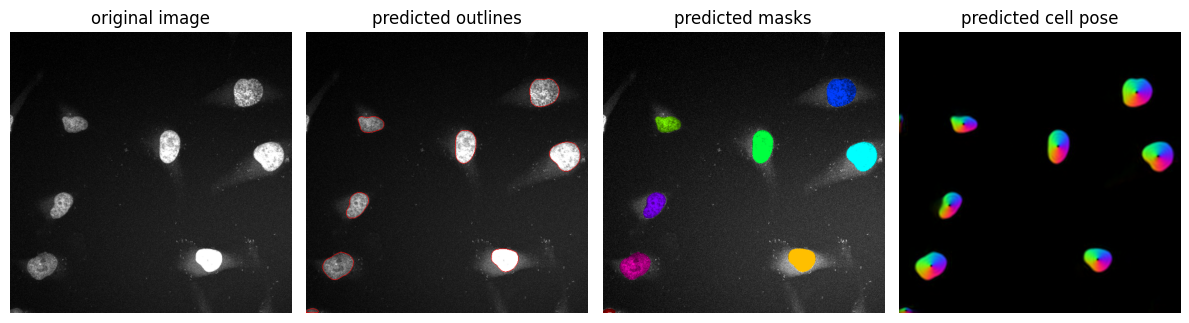

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt
from cellpose import plot

channels = [0]
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, nuclei_image_MIP.squeeze(), nuclei_labels, flows_nuclei[0], channels=channels)
plt.tight_layout()
plt.show()

## Relate the nuclei and cytoplasmic labels

In [50]:
import numpy as np
from skimage.measure import regionprops
from scipy import stats

def relate_labels(nuclei_labels, cell_labels, mode='majority'):
    """
    Relabels nuclei to match cell IDs. Works for 2D and 3D.
    
    Modes:
    - 'centroid': Uses the center point of the nucleus.
    - 'majority': Uses the cell ID that covers most of the nucleus area.
    - 'strict': Only assigns if the nucleus is fully (100%) inside one cell.
    """
    new_nuclei = np.zeros_like(nuclei_labels)
    props = regionprops(nuclei_labels)

    for prop in props:
        coords = prop.coords  # Get all pixel coordinates for this nucleus
        # Get the cell IDs at those specific coordinates
        # For 3D, coords will be (N, 3); for 2D, (N, 2)
        indices = tuple(coords.T)
        overlapping_cell_ids = cell_labels[indices]
        
        # Filter out background (0)
        valid_cells = overlapping_cell_ids[overlapping_cell_ids > 0]

        if valid_cells.size == 0:
            continue # Nucleus is in the background, leave as 0

        if mode == 'centroid':
            # Find cell ID at the exact center
            center = tuple(prop.centroid.astype(int))
            target_id = cell_labels[center]
            
        elif mode == 'majority':
            # Find the most frequent cell ID under the nucleus mask
            target_id = stats.mode(valid_cells, keepdims=True)[0][0]
            
        elif mode == 'strict':
            # Check if all pixels belong to the same non-zero ID
            first_id = valid_cells[0]
            if np.all(overlapping_cell_ids == first_id):
                target_id = first_id
            else:
                target_id = 0 # Discard if it touches multiple cells or background

        # Apply the new ID to all pixels of this nucleus
        new_nuclei[indices] = target_id

    return new_nuclei

In [51]:
 nuclei_labels_related = relate_labels(nuclei_labels,cyto_labels,  mode='majority')

In [52]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(cell_labels, nuclei_before, nuclei_after, slice_idx=None):
    """
    Plots Cells, Nuclei Before, and Nuclei After.
    For 3D images, specify a slice_idx.
    """
    # Handle 3D slicing
    if cell_labels.ndim == 3:
        if slice_idx is None:
            slice_idx = cell_labels.shape[0] // 2
        c = cell_labels[slice_idx]
        nb = nuclei_before[slice_idx]
        na = nuclei_after[slice_idx]
    else:
        c, nb, na = cell_labels, nuclei_before, nuclei_after

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Use a random colormap to make label differences obvious
    cmap = 'nipy_spectral' 

    axes[0].imshow(c, cmap=cmap)
    axes[0].set_title("Original Cell Labels")
    axes[0].axis('off')

    axes[1].imshow(nb, cmap=cmap)
    axes[1].set_title("Nuclei Before (Random IDs)")
    axes[1].axis('off')

    axes[2].imshow(na, cmap=cmap)
    axes[2].set_title("Nuclei After (Synced IDs)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Example call:
# plot_comparison(cells, original_nuclei, synchronized_nuclei)

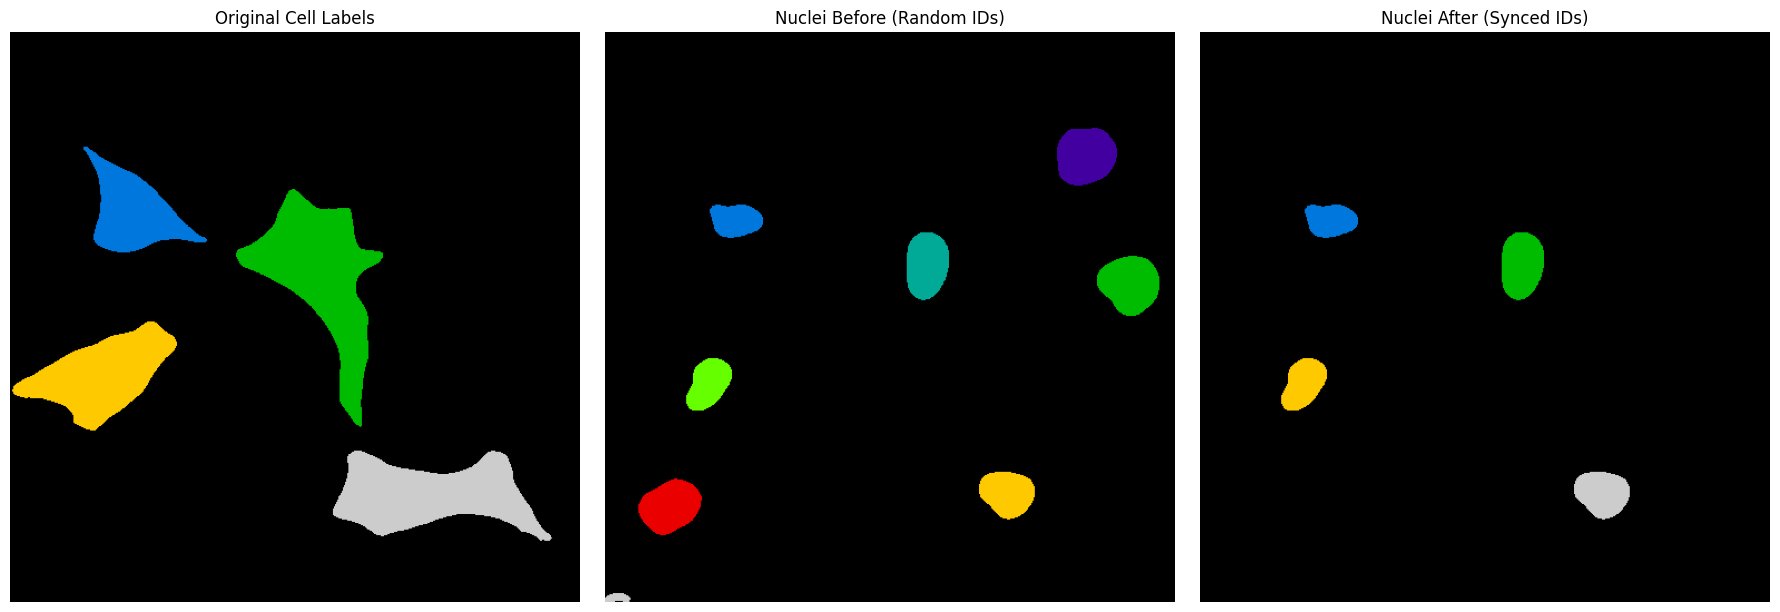

In [53]:
plot_comparison(cyto_labels,nuclei_labels, nuclei_labels_related, slice_idx=None)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries


def plot_segmentation_overlay(raw_image, cell_labels, nuclei_labels, slice_idx=None, alpha=0.4, title="Synced Overlay"):
    """
    Plots Raw Image + Transparent Cell Labels + Nucleus Outlines.
    """
    # 1. Handle 3D slicing
    if raw_image.ndim == 3:
        idx = slice_idx if slice_idx is not None else raw_image.shape[0] // 2
        img_slice = raw_image[idx]
        c_slice = cell_labels[idx]
        n_slice = nuclei_labels[idx]
    else:
        img_slice, c_slice, n_slice = raw_image, cell_labels, nuclei_labels

    # Determine the global range so colors are locked to specific IDs
    v_min, v_max = 0, max(cell_labels.max(), nuclei_labels.max())
    
    plt.figure(figsize=(10, 10))
    
    # Layer 1: Raw Image
    plt.imshow(img_slice, cmap='gray')

    # Layer 2: Cells (Filtered for background)
    c_masked = np.ma.masked_where(c_slice == 0, c_slice)
    plt.imshow(c_masked, cmap='nipy_spectral', alpha=alpha, vmin=v_min, vmax=v_max)

    # Layer 3: Nuclei (Filtered for background)
    # We plot the nuclei as solid or outlines, but with the SAME vmin/vmax
    n_masked = np.ma.masked_where(n_slice == 0, n_slice)
    plt.imshow(n_masked, cmap='nipy_spectral', alpha=0.4, vmin=v_min, vmax=v_max)

    plt.title(f"{title}\n(Solid = Cells, Outlines = Synced Nuclei)")
    plt.axis('off')
    plt.show()

# Usage:
# plot_full_overlay(raw_data, cell_labels, synced_nuclei, alpha=0.3)

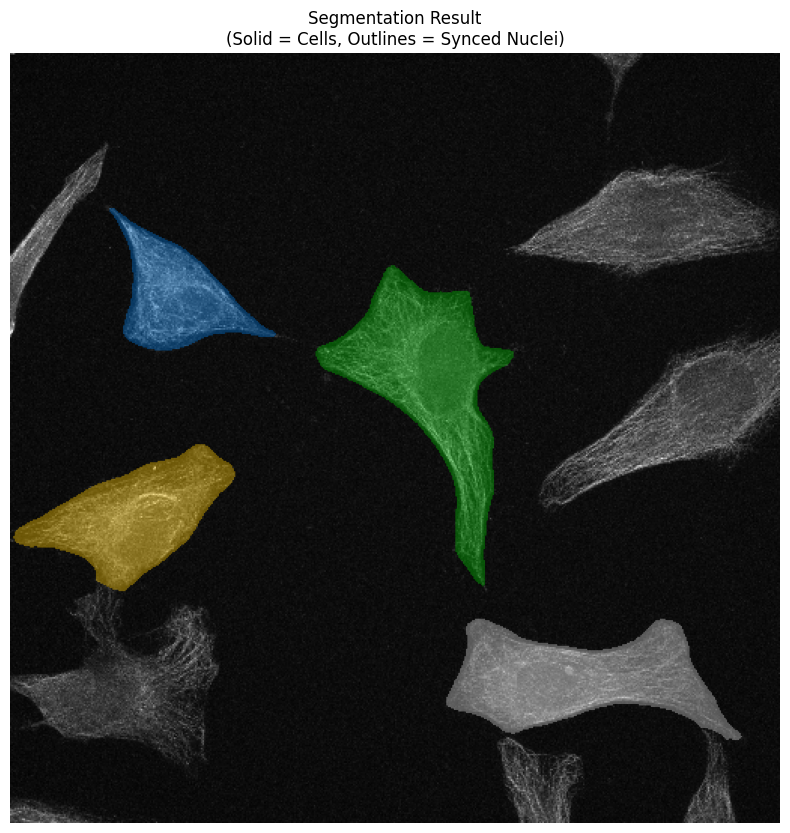

In [74]:
plot_segmentation_overlay(nuclei_cell_image_MIP[0].squeeze(), cyto_labels,nuclei_labels_related, slice_idx=None, title="Segmentation Result")